   Index        Date      Time  Longitude  Latitude  Magnitude  Depth  \
0      1  2021-01-01   6:07:09     101.27     26.24        3.0     16   
1      2  2021-01-02   4:24:34      94.62     36.86        3.5      9   
2      3  2021-01-02  21:26:48     122.24     24.07        4.4     24   
3      4  2021-01-03   2:40:25      99.92     25.63        3.2     11   
4      5  2021-01-03   8:34:38     117.70     24.69        3.0     28   

                                 Location  
0                            Dayao,Yunnan  
1                          Geermu,Qinghai  
2  ThecoastalareanearHualian,Taiwan,China  
3                           Yangbi,Yunnan  
4                         Changtai,Fujian  
Index(['Index', 'Date', 'Time', 'Longitude', 'Latitude', 'Magnitude', 'Depth',
       'Location'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 695 entries, 0 to 694
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   I

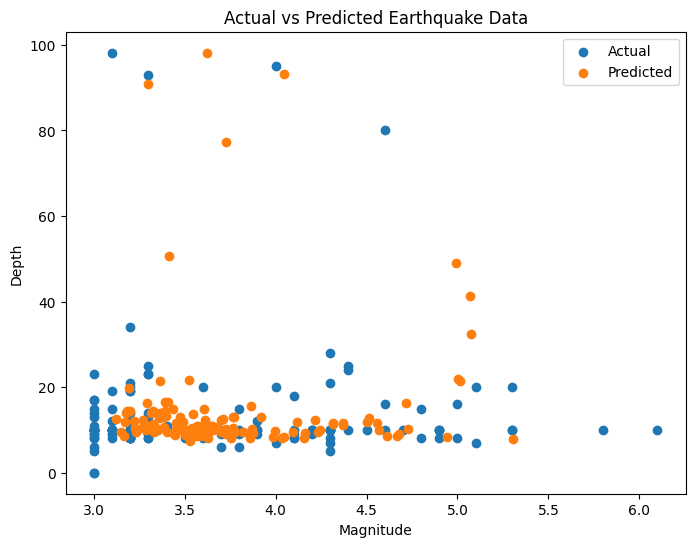

MSE Magnitude: 0.5311680863309357
MSE Depth: 235.97890647482015


NameError: name 'ab1' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("data.csv")

print(df.head())
print(df.columns)
print(df.info())
print(df.isnull().sum())

df = df[['Date', 'Time', 'Latitude', 'Longitude', 'Depth', 'Magnitude']]

timestamps = []

for d, t in zip(df['Date'], df['Time']):
    dt = datetime.strptime(str(d) + " " + str(t), "%Y-%m-%d %H:%M:%S")
    timestamps.append(int(dt.timestamp()))

df['Timestamp'] = timestamps

df = df.drop(['Date', 'Time'], axis=1)

X = df[['Timestamp', 'Latitude', 'Longitude']]
y = df[['Magnitude', 'Depth']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestRegressor()

params = {
    'n_estimators': [50, 100, 200]
}

grid = GridSearchCV(model, params, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

plt.figure(figsize=(8,6))

# Actual values
plt.scatter(y_test['Magnitude'], y_test['Depth'], label='Actual')

# Predicted values
plt.scatter(y_pred[:,0], y_pred[:,1], label='Predicted')

plt.xlabel("Magnitude")
plt.ylabel("Depth")
plt.title("Actual vs Predicted Earthquake Data")
plt.legend()

plt.savefig("images/output.png")
plt.show()

from sklearn.metrics import mean_squared_error

mse_mag = mean_squared_error(y_test['Magnitude'], y_pred[:,0])
mse_depth = mean_squared_error(y_test['Depth'], y_pred[:,1])

print("MSE Magnitude:", mse_mag)
print("MSE Depth:", mse_depth)


